In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def w(n):
    return np.exp((1j * 2 * np.pi)/n)

In [3]:
def w_ij(n):
    w_base = w(n)
    def value_ij(i, j):
        return w_base**(i * j)
    return value_ij

In [4]:
def slow_fourier_transform(samples):
    n = len(samples)
    creator_function = w_ij(n)
    transformer_matrix = np.fromfunction(creator_function, (n, n))
    return (1/n) *  (transformer_matrix @ samples)

In [5]:
def construct_function(c_k):
    def f(x):
        result = 0
        for (i, weight) in enumerate(c_k):
            result += weight * (np.cos(i * x) - np.sin(i * x) * 1j)
        return result
    return f

In [6]:
samples = np.array([1, -2, 4, -8, 16, -32])

In [7]:
c_k = slow_fourier_transform(samples)

In [8]:
f = construct_function(c_k)

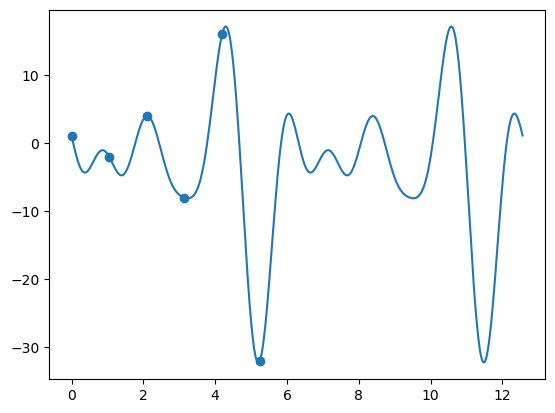

In [9]:
ts = np.arange(0, 4 * np.pi, 0.02)
sample_percentage = np.arange(0, len(samples), 1)/len(samples)
plt.scatter(2 * np.pi * sample_percentage, samples)
plt.plot(ts, np.real(f(ts)))

<BarContainer object of 6 artists>

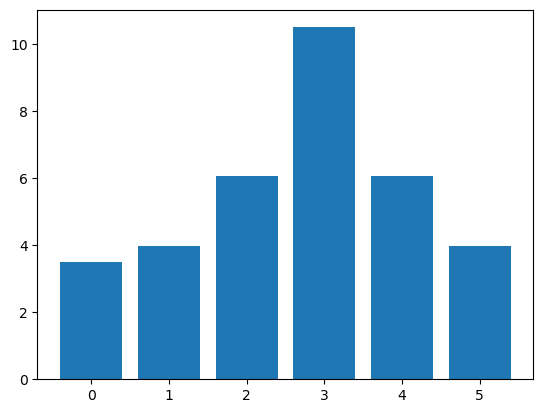

In [10]:
plt.bar(np.arange(len(c_k)), abs(c_k))